In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [2]:
df = pd.read_csv('..\merged_datasets\preprocessed_reduced_data_unsupervised_10 (1).csv')
df 

,ae_feature_0,ae_feature_1,ae_feature_2,ae_feature_3,ae_feature_4,ae_feature_5,ae_feature_6,ae_feature_7,ae_feature_8,ae_feature_9
0,-0.119615,0.014409,0.289485,0.268099,1.141023,0.828820,-0.070544,0.132453,-0.009375,0.050310
1,0.252335,-1.366369,-0.503386,0.075595,1.510489,0.045589,0.638531,0.301778,-0.196644,0.151572
2,0.069489,0.912729,0.197357,0.510982,1.047960,0.322084,-1.178616,-0.770996,-0.135676,-0.231922
3,-2.621144,-0.579182,-1.420516,1.236287,-0.860376,-0.411838,-0.074765,-0.965203,-0.961106,-1.625318
4,5.008158,-0.195180,0.026139,0.424416,-4.094203,0.695084,0.069072,-0.349306,0.579301,0.052082
...,...,...,...,...,...,...,...,...,...,...
211484,5.539144,0.390150,0.409052,0.372047,-2.906549,0.011980,-0.694124,0.777210,0.592415,0.219165
211485,-0.311200,0.098255,0.783207,-1.100208,0.300466,-0.479691,0.754973,0.637632,0.778620,-0.565327
211486,0.294379,-0.841815,-0.346881,0.715200,2.027311,0.461459,0.128530,0.402791,-0.366206,-0.555080
211487,0.997730,1.717806,0.297137,1.011535,0.244105,1.403261,-0.156626,-0.172443,-0.133348,-0.210979


In [ ]:
import numpy as np

class DBSCANFromScratch:
    def __init__(self, eps, min_samples):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def _euclidean_distance(self, p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))

    def _region_query(self, X, point_idx):
        """
        Finds all indices of points within 'eps' distance of X[point_idx].
        Uses Vectorization (NumPy) for speed instead of a loop.
        """
        # Calculate distance from point_idx to ALL other points
        distances = np.sqrt(np.sum((X - X[point_idx])**2, axis=1))
        
        # Return indices where distance is less than epsilon
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X, point_idx, neighbors, current_cluster_id, visited):
        """
        Expands the cluster from a core point to all reachable density-connected points.
        """
        # Assign the core point to the cluster
        self.labels_[point_idx] = current_cluster_id
        
        # Iterate through neighbors (using a while loop because the list grows)
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]
            
            if neighbor_idx not in visited:
                visited.add(neighbor_idx)
                
                # Check if this neighbor is ALSO a core point
                new_neighbors = self._region_query(X, neighbor_idx)
                
                if len(new_neighbors) >= self.min_samples:
                    # If it is a core point, join its neighbors to our list
                    neighbors = np.concatenate((neighbors, new_neighbors))
            
            # If the neighbor is not yet part of a cluster (or was noise), assign it
            if self.labels_[neighbor_idx] == -1: # previously noise
                 self.labels_[neighbor_idx] = current_cluster_id
            elif self.labels_[neighbor_idx] == 0: # unassigned
                 self.labels_[neighbor_idx] = current_cluster_id
                 
            i += 1

    def fit_predict(self, X):
        """
        Main DBSCAN loop.
        X: Numpy array of shape (n_samples, n_features)
        """
        n_samples = X.shape[0]
        self.labels_ = np.zeros(n_samples, dtype=int) # 0 indicates unvisited/unlabeled initially
        visited = set()
        
        cluster_id = 0
        
        for point_idx in range(n_samples):
            if point_idx in visited:
                continue
            
            visited.add(point_idx)
            
            # Get neighbors
            neighbors = self._region_query(X, point_idx)
            
            if len(neighbors) < self.min_samples:
                # Mark as Noise (-1)
                self.labels_[point_idx] = -1
            else:
                # Found a Core Point -> Start a new cluster
                cluster_id += 1
                self._expand_cluster(X, point_idx, neighbors, cluster_id, visited)
                
        # Scikit-learn convention: Clusters start at 0, Noise is -1.
        # My code made clusters start at 1, so let's adjust them down by 1.
        # But we must keep Noise as -1.
        final_labels = np.array(self.labels_)
        mask_clusters = final_labels > 0
        final_labels[mask_clusters] = final_labels[mask_clusters] - 1
        
        return final_labels

# --- HOW TO RUN IT ---


# 1. Prepare the data
# We drop the target column

# --- CRITICAL FIX ---
# Convert DataFrame to a Numpy Array immediately.
# This fixes the KeyError because Numpy arrays support [list_of_indices] slicing.
X_data = df.values 

# 3. Initialize the custom model
# Since data is scaled, eps=0.5 is a reasonable starting point

custom_dbscan = DBSCANFromScratch(eps=0.5, min_samples=10)

# 4. Run
labels = custom_dbscan.fit_predict(X_data)

# 5. Check results
print(f"Unique labels found: {np.unique(labels)}")
print(f"Number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")

Unique labels found: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 238 239 2

In [4]:

# Count the points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
percent_noise = (n_noise / len(labels)) * 100

print(f"--- Basic Stats ---")
print(f"Estimated number of clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({percent_noise:.2f}%)")

# Interpretation guide
if percent_noise > 90:
    print("Warning: Too much noise! Increase 'eps' or decrease 'min_samples'.")
elif n_clusters < 2 and percent_noise < 10:
    print("Warning: Everything is one giant cluster! Decrease 'eps'.")
else:
    print("Status: Clustering looks structurally balanced.")

--- Basic Stats ---
Estimated number of clusters: 736
Noise points: 13045 (6.17%)
Status: Clustering looks structurally balanced.


In [5]:
from sklearn.metrics import silhouette_score

# Create a mask to select only points that belong to a cluster (not noise)
mask = labels != -1

if sum(mask) > 1 and n_clusters > 1:
    # Calculate score only on clustered data
    score = silhouette_score(X_data[mask], labels[mask])
    print(f"Silhouette Score: {score:.4f}")
else:
    print("Silhouette Score: Cannot calculate (Need at least 2 clusters and valid points).")

Silhouette Score: 0.1005


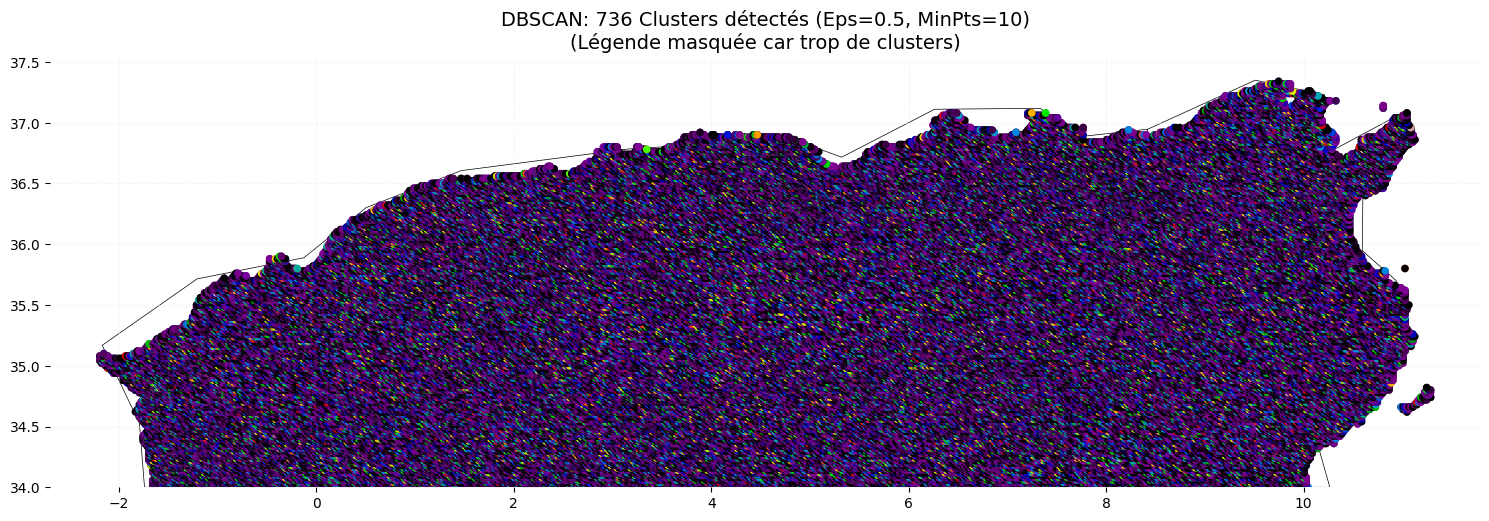

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

# ==========================================
# 2. CHARGEMENT DES COORDONNÉES ET FUSION
# ==========================================

# Chargement du fichier contenant ID, Lat, Lon
coords = pd.read_csv("../cleaned_datasets/long_lat_attributes.csv")

# Identification des colonnes lat/lon
lat_col = [c for c in coords.columns if 'lat' in c.lower()][0]
lon_col = [c for c in coords.columns if 'lon' in c.lower() or 'long' in c.lower()][0]

# --- FUSION ---
# On crée une copie pour le plot
df_plot = coords.copy()

# IMPORTANT : On assigne les clusters trouvés par DBSCAN aux coordonnées.
# Cela suppose que l'ordre des lignes est IDENTIQUE entre 'df' et 'coords'.
# Si 'df' a été mélangé (shuffled), il faut fusionner sur une colonne 'ID' commune.
if len(df_plot) == len(labels):
    df_plot['cluster'] = labels
else:
    print(f"ERREUR : Le nombre de lignes du dataset ({len(labels)}) diffère des coordonnées ({len(df_plot)}).")
    # Si vous avez des IDs, faites plutôt : df_plot = pd.merge(coords, df_with_ids[['id', 'cluster']], on='id')

# ==========================================
# 3. PRÉPARATION DE LA CARTE (CLIP)
# ==========================================

world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(world_url)
countries = world[world['name'].isin(["Algeria", "Tunisia"])]

xmin, ymin, xmax, ymax = countries.total_bounds
# Clipping pour se concentrer sur le nord (34°N - 40°N)
clipping_rect = box(xmin, 34, xmax, 40) 
countries_clipped = countries.clip(clipping_rect)

# ==========================================
# 4. VISUALISATION CORRIGÉE
# ==========================================

# Filtrage pour l'affichage (Latitude > 34)
df_filtered = df_plot[df_plot[lat_col] > 34].copy()

# Création du GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_filtered,
    geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(15, 12)) # Carte un peu plus grande

# 1. Fond de carte
countries_clipped.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5, zorder=1)

# 2. Affichage du Bruit (-1)
# On l'affiche en gris clair pour qu'il ne gêne pas la lecture
gdf_noise = gdf[gdf['cluster'] == -1]
if not gdf_noise.empty:
    gdf_noise.plot(
        ax=ax,
        color='#E0E0E0', # Gris très clair
        markersize=5,    # Points plus petits
        alpha=0.3,       # Plus transparent
        zorder=2
    )

# 3. Affichage des Clusters
gdf_clusters = gdf[gdf['cluster'] != -1].copy()

if not gdf_clusters.empty:
    # ASTUCE : Pour éviter que deux clusters voisins aient une couleur trop proche
    # dans le dégradé, on peut mélanger les labels juste pour l'affichage (optionnel)
    # gdf_clusters['random_color_id'] = gdf_clusters['cluster'].sample(frac=1).values
    
    gdf_clusters.plot(
        column='cluster',   # Colonne à colorier
        ax=ax,
        categorical=True,   # Traiter comme catégories
        legend=False,       # <--- DÉSACTIVER LA LÉGENDE (Trop de clusters)
        cmap='nipy_spectral', # <--- Palette avec beaucoup de contraste
        markersize=20,
        alpha=1,
        zorder=3
    )

# Configuration axes
ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)

# Suppression des bordures
for spine in ax.spines.values():
    spine.set_visible(False)

# Titre
plt.title(f"DBSCAN: {n_clusters} Clusters détectés (Eps={0.5}, MinPts={10})\n(Légende masquée car trop de clusters)", fontsize=14)
ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)

plt.tight_layout()
plt.show()